In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')

| 컬럼명              | 설명                                      | 타입      | 비고                                   |
|---------------------|-----------------------------------------|-----------|----------------------------------------|
| ID                  | 샘플별 고유 ID                           | 문자열     | 학습에 불필요, 제출 시 식별자로 사용   |
| age                 | 고객 나이                                | 수치형     | —                                      |
| gender              | 고객 성별                                | 범주형     | 예: M / F                              |
| tenure              | 고객이 서비스를 이용한 총 기간 (월)       | 수치형     | —                                      |
| frequent            | 고객의 서비스 이용일                     | 수치형     | —                                      |
| payment_interval    | 고객의 결제 지연일                       | 수치형     | —                                      |
| subscription_type   | 고객의 서비스 등급                       | 범주형     | 예: member, plus, vip                  |
| contract_length     | 고객의 서비스 계약 기간 (일)              | 수치/범주형 | 30, 90, 360 등                          |
| after_interaction   | 최근 서비스 이용으로부터 경과한 기간 (일) | 수치형     | —                                      |
| support_needs       | 고객의 지원 필요도 (0: 낮음, 1: 중간, 2: 높음) | 레이블     | **타깃 변수**                           |

In [4]:
train = pd.read_csv('./train.csv')
test = pd.read_csv('./test.csv')

train.head()

,ID,age,gender,tenure,frequent,payment_interval,subscription_type,contract_length,after_interaction,support_needs
0,TRAIN_00000,54.0,F,47.0,22.0,8.0,member,90,25.0,0
1,TRAIN_00001,30.0,M,16.0,15.0,5.0,vip,360,23.0,0
2,TRAIN_00002,29.0,M,8.0,30.0,21.0,plus,30,21.0,0
3,TRAIN_00003,38.0,F,38.0,23.0,10.0,vip,90,6.0,0
4,TRAIN_00004,25.0,F,52.0,3.0,17.0,member,30,1.0,2


In [7]:
print(train.shape, test.shape)
train.info()

(30858, 10) (13225, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30858 entries, 0 to 30857
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 30858 non-null  object 
 1   age                30858 non-null  float64
 2   gender             30858 non-null  object 
 3   tenure             30858 non-null  float64
 4   frequent           30858 non-null  float64
 5   payment_interval   30858 non-null  float64
 6   subscription_type  30858 non-null  object 
 7   contract_length    30858 non-null  int64  
 8   after_interaction  30858 non-null  float64
 9   support_needs      30858 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 2.4+ MB


Axes(0.125,0.11;0.775x0.77)


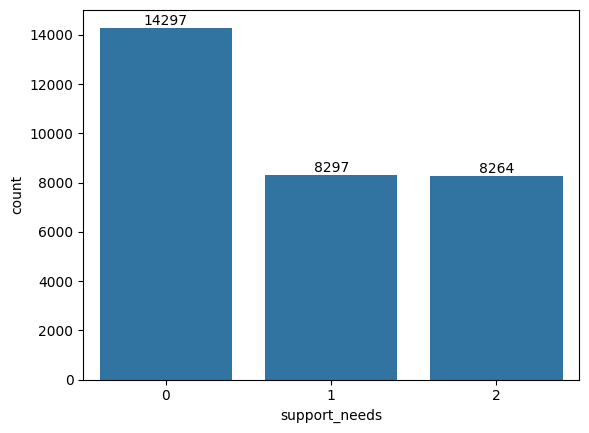

In [ ]:
ax = sns.countplot(data=train, x = 'support_needs')
ax.bar_label(ax.containers[0])
plt.show()

In [21]:
print(train['support_needs'].value_counts())
total_cnt = train['support_needs'].count()
print('고객 지원 필요도 0의 비율은 {0:.4f}'.format(train['support_needs'].value_counts()[0] / total_cnt))
print('고객 지원 필요도 1의 비율은 {0:.4f}'.format(train['support_needs'].value_counts()[1] / total_cnt))
print('고객 지원 필요도 2의 비율은 {0:.4f}'.format(train['support_needs'].value_counts()[2] / total_cnt))

support_needs
0    14297
1     8297
2     8264
Name: count, dtype: int64
고객 지원 필요도 0의 비율은 0.4633
고객 지원 필요도 1의 비율은 0.2689
고객 지원 필요도 2의 비율은 0.2678


In [22]:
train.describe()

,age,tenure,frequent,payment_interval,contract_length,after_interaction,support_needs
count,30858.000000,30858.000000,30858.000000,30858.000000,30858.000000,30858.000000,30858.000000
mean,39.428479,31.250275,15.803876,12.947145,186.643010,14.546147,0.804492
std,12.423977,17.403133,8.612354,8.302702,143.948206,8.599893,0.832419
min,18.000000,1.000000,1.000000,0.000000,30.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,6.000000,90.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,12.000000,90.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,19.000000,360.000000,22.000000,2.000000
max,65.000000,60.000000,30.000000,30.000000,360.000000,30.000000,2.000000


In [23]:
train.info().Dtype == 'object'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30858 entries, 0 to 30857
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 30858 non-null  object 
 1   age                30858 non-null  float64
 2   gender             30858 non-null  object 
 3   tenure             30858 non-null  float64
 4   frequent           30858 non-null  float64
 5   payment_interval   30858 non-null  float64
 6   subscription_type  30858 non-null  object 
 7   contract_length    30858 non-null  int64  
 8   after_interaction  30858 non-null  float64
 9   support_needs      30858 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 2.4+ MB


AttributeError: 'NoneType' object has no attribute 'Dtype'